# Práctica de Percepción: Estimación de movimiento
## Introducción
En esta práctica veremos como estimar el movimiento en imágenes. Para ello se utilizará OpenCV, NumPy y Matplotlib. 

## Ejercicio 1: Estimación por diferencia
Objetivos: Representar la zona de movimiento por diferencia de imágenes.

/home/antonio/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


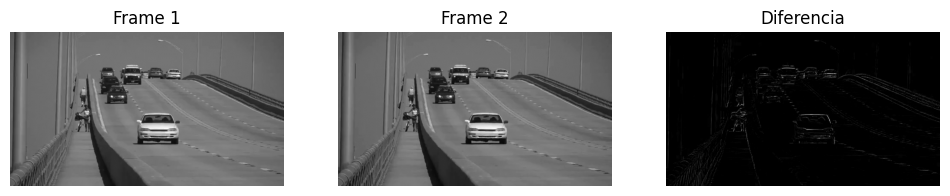

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar el vídeo
video_path = "slow_traffic_small.mp4"  # cambia por tu fichero
cap = cv2.VideoCapture(video_path)

# Leer dos frames consecutivos
ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

if not ret1 or not ret2:
    print("Error al leer el vídeo")
else:
    # Convertir a escala de grises
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Diferencia absoluta
    diff = cv2.subtract(gray1, gray2)

    # Mostrar resultados
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.title("Frame 1")
    plt.imshow(gray1, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Frame 2")
    plt.imshow(gray2, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Diferencia")
    plt.imshow(diff, cmap='gray')
    plt.axis('off')

    plt.show()

cap.release()

Ejercicio propuesto: Aplicarlo y mostrarlo de manera continua en un video.

In [2]:
#TODO

## Ejercicio 2: Optical Flow (Lucas-Kanade)
Objetivos: Calcular el flujo óptico entre frames usando el método de Lucas-Kanade (LK).

In [ ]:
cap = cv2.VideoCapture(video_path)

# Parámetros para detección de esquinas
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# Parámetros de Lucas-Kanade
lk_params = dict(
    winSize=(15,15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

# Leer primer frame
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# Detectar puntos de interés
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# Crear máscara para dibujar
mask = np.zeros_like(old_frame)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calcular optical flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # Seleccionar buenos puntos
    good_new = p1[st==1]
    good_old = p0[st==1]

    # Dibujar trayectorias
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()

        mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), (0,255,0), 2)
        frame = cv2.circle(frame, (int(a), int(b)), 5, (0,0,255), -1)

    img = cv2.add(frame, mask)

    cv2.imshow('Optical Flow LK', img)

    if cv2.waitKey(30) & 0xFF == 27:  # ESC para salir
        break

    # Actualizar
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1,1,2)

cap.release()
cv2.destroyAllWindows()

## Ejercicio 3: Dense Optical Flow (Horn-Schunck)
Objetivos: Calcular el flujo óptico entre frames usando el método de Horn-Schunck.

Referencias: https://datahacker.rs/013-optical-flow-using-horn-and-schunck-method/ y https://www.geeksforgeeks.org/python/opencv-the-gunnar-farneback-optical-flow/

In [ ]:
#TO DO 